In [1]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA , NVIDIAEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document

from langgraph.graph import StateGraph , START , END

from dotenv import load_dotenv
from pydantic import BaseModel , Field
from typing import TypedDict , List , Literal

import time

d:\GenAI\LangGraph\myenvAI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
docs = (

    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Policies.pdf').load() + 
    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Profile.pdf').load() + 
    PyPDFLoader(r'D:\GenAI\LangGraph\document\Company_Policies.pdf').load()
)

In [4]:
# Text splitting
chunk = RecursiveCharacterTextSplitter(chunk_size = 600 , chunk_overlap = 150).split_documents(docs)

In [5]:
embedding = NVIDIAEmbeddings()
vector_store = FAISS.from_documents(chunk , embedding)
retriever = vector_store.as_retriever(search_kwargs = {'k' : 4})

In [6]:
llm = ChatNVIDIA(model = 'openai/gpt-oss-120b')

In [27]:
# Define state
class State(TypedDict):
    question : str
    need_retrieval : bool

    docs : List[Document]
    relevant_docs : List[Document]

    context : str
    answer : str

    # What we actually send to vector retriever
    retrieval_query : str
    rewrite_query : str
    rewrite_tries : int

    # Post-generation verification
    is_sup : Literal['fully_support' , 'partially_support' , 'no_support']
    evidence : list[str]

    retries : int

    # usefulness check
    is_use : Literal['useful' , 'not_useful']
    use_reason : str

In [28]:
class RetrieverDecision(BaseModel):
    should_retrieve : bool = Field(... , description='True if external documents are needed to answer relaibly, else False')


decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'You decide whether retrieval is needed.\n'
            'Return JSON that matches this schema:\n'
            '{{should_retrieve : boolan}}\n\n'
            'Guidelines:\n'
            '- Should_retrieve=True if answering requires specific facts, citations , info likely not in the model.\n'
            '- Should_retrieve=False for general explanations , definations, or reasoning that does not need source.\n'
            '- If unsure , choose True'
        ),
        ('human' , 'Question : {question}'),
    ]
)

# IMPORTANT : no content for structure output
should_retrieve_llm = llm.with_structured_output(RetrieverDecision)


def decide_retrieval(state : State):

    decision : RetrieverDecision = should_retrieve_llm.invoke(

        decide_retrieval_prompt.format_messages(question= state['question'])
    )

    return {'need_retrieval' : decision.should_retrieve}



# helper function (For Routing)
def route_after_decide(state : State) -> Literal['generate_direct' , 'retrieve']:

    if state['need_retrieval']:
        return 'retrieve'
    
    else:
        return 'generate_direct'

In [29]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'Answer the question using only your general knowledge.\n'
            'Do NOT assume access to external documents.\n'
            'If you unsure or the answer require specific sources, say:\n'
            'I do not know based on my general knowledge.'
        ),
        ('human' , '{question}')
    ]
)

def generate_direct(state : State):

    out = llm.invoke(

        direct_generation_prompt.from_messages(question = state['question'])
    )

    return {'answer' : out.content}

In [30]:
def retrieve(state : State):

    question = state.get('retrieval_query') or state['question']
    return {'docs' : retriever.invoke(question)}

In [31]:
class RelavenceDecision(BaseModel):

    is_relevant : bool = Field(... , description='True if the documnent helps answer the question , else False')

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)

relevance_llm = llm.with_structured_output(RelavenceDecision)

def is_relevant(state : State):

    relevant_doc : List[Document] = []

    for doc in state.get('docs'):

        decision : RelavenceDecision = relevance_llm.invoke(

            is_relevant_prompt.format_messages(
                question = state['question'],
                document = doc.page_content
            )
        )


        if decision.is_relevant:
            relevant_doc.append(doc)


    return {'relevant_docs' : relevant_doc}



# helper function(Routing function) Routing after relevant
def route_after_relevance(state : State) -> Literal['generate_from_context' , 'no_relevant_docs']:

    if state['relevant_docs'] and len(state['relevant_docs']) > 0:
        return 'generate_from_context'
    
    else:
        return 'no_relevant_docs'

In [32]:
rag_generate_prompt = ChatPromptTemplate.from_messages(
    [
        (
            'system',
            'You are a business RAG asisstant.\n'
            'Answer the user question using ONLY the provided context.\n'
            'If the context does not contain enough information , say.\n'
            'NO relevant document found.\n'
            'Do not use outsider knowledge.\n'
        ),
        (
            'human',
            'Question : \n{question}\n\n'
            'Context  : \n{context}\n\n'
        )
    ]
)

def generate_from_context(state : State):

    # stuff relevant docs into one block
    context = '\n\n'.join([d.page_content for d in state.get('relevant_docs' , [])]).strip()

    if not context:
        return {'answer' : 'No answer found.' , 'context' : ''}
    

    out = llm.invoke(

        rag_generate_prompt.format_messages(
            question = state['question'],
            context = context
        )
    )

    return {'answer' : out.content , 'context' : context}

In [33]:
def no_answer_found(state : State):
    
    return {'answer' : 'No answer found.' , 'context' : ''}

In [34]:
class IsSUPDecision(BaseModel):

    is_sup : Literal['fully_support' , 'paritally_support' , 'no_support']
    evidence : List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
            
        ),
    ]
)


issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state : State):

    decision : IsSUPDecision = issup_llm.invoke(

        issup_prompt.format_messages(
            question = state['question'],
            answer = state['answer'],
            context = state['context']
        )
    )

    return {'is_sup' : decision.is_sup , 'evidence' : decision.evidence}



MAX_RETRIES = 10

# Routing function(Routing after is_support document)
def route_after_issup(state : State):

    # accept fi fully support
    if state.get('is_sup') == 'fully_support':
        return 'accept_answer'
    
    # Stop if we have already tried enough
    if state.get('retries' , 0) >= MAX_RETRIES:
        return 'accept_answer'
    
    # otherwise revise again
    return 'revise_answer'

In [35]:
def accept_answer(state : State):
    return {}

In [36]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)


def revise_answer(state : State):

    out = llm.invoke(

        revise_prompt.format_messages(
            question = state['question'],
            answer = state['answer' , ''],
            context = state['context' , '']
        )
    )

    return {

        'answer' : out.content,
        'retries' : state.get('retries' , 0) + 1
    }

In [42]:
class IsUseful(BaseModel):

    is_use : Literal['useful' , 'not_useful']
    reason : str

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = llm.with_structured_output(IsUseful)


def is_use(state : State):

    decision : IsUseful = isuse_llm.invoke(

        isuse_prompt.format(

            question = state.get('question'),
            answer = state.get('answer' , '')
        )
    )

    return {'is_use' : decision.is_use , 'use_reason' : decision.reason}


def route_after_isuse(state : State):

    if state.get('is_use') == 'useful':
        return 'END'
    
    return 'no_answer_found'

In [43]:
class ReWriteDecision(BaseModel):
    retrieval_query : str = Field(description='ReWritten query optimized for vector retrieval againest internal company PDFs.')


rewrite_for_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)

rewrite_llm = llm.with_structured_output(ReWriteDecision)

def rewrite_question(state : State):

    decision : ReWriteDecision = rewrite_llm.invoke(

        rewrite_for_relevant_prompt.from_messages(
            question = state.get('question'),
            retrieval_query = state.get('retrieval_query' , ''),
            answer = state.get('answer')
        )
    )

    return {

        'retrieval_query' : decision.retrieval_query,
        'rewrite_tries' : state.get('rewrite_tries' , 0) + 1,
        
        # optional : reset the state values so that next tries state is clean
        'docs' : [],
        'relevant_docs' : [],
        'context' : ''
    }


In [44]:
builder = StateGraph(State)

# Add nodes
builder.add_node('decide_retrieval' , decide_retrieval)
builder.add_node('generate_direct' , generate_direct)
builder.add_node('retrieve' , retrieve)

builder.add_node('is_relevant' , is_relevant)
builder.add_node('generate_from_context' , generate_from_context)
builder.add_node('no_answer_found' , no_answer_found)

builder.add_node('is_sup' , is_sup)
builder.add_node('revise_answer' , revise_answer)

builder.add_node('is_use' , is_use)
builder.add_node('rewrite_query' , rewrite_question)
builder.add_node('accept_answer' , accept_answer)

# Add edges
builder.add_edge(START , 'decide_retrieval')

builder.add_conditional_edges(
    'decide_retrieval',

    route_after_decide,
    {
        'generate_direct' : 'generate_direct',
        'retrieve' : 'retrieve'
    }
)

builder.add_edge('generate_direct' , END)


builder.add_edge('retrieve' , 'is_relevant')

builder.add_conditional_edges(
    'is_relevant',

    route_after_relevance,
    {
        'generate_from_context' : 'generate_from_context',
        'no_answer_found' : 'no_answer_found'
    }
)


builder.add_edge('generate_from_context' , 'is_sup')

builder.add_conditional_edges(
    'is_sup',

    route_after_issup,
    {
        'accept_answer' : 'accept_answer',
        'revise_answer' : 'revise_answer'
    }
)

builder.add_edge('revise_answer' , 'is_sup')
builder.add_edge('accept_answer' , 'is_use')

builder.add_conditional_edges(
    'is_use',

    route_after_isuse,
    {
        'END' : END,
        'rewrite_query' : 'rewrite_query',
        'no_answer_found' : 'no_answer_found'
    }
)
builder.add_edge('no_answer_found' , END)

builder.add_edge('rewrite_query' , 'retrieve')


# compile the graph

app = builder.compile()

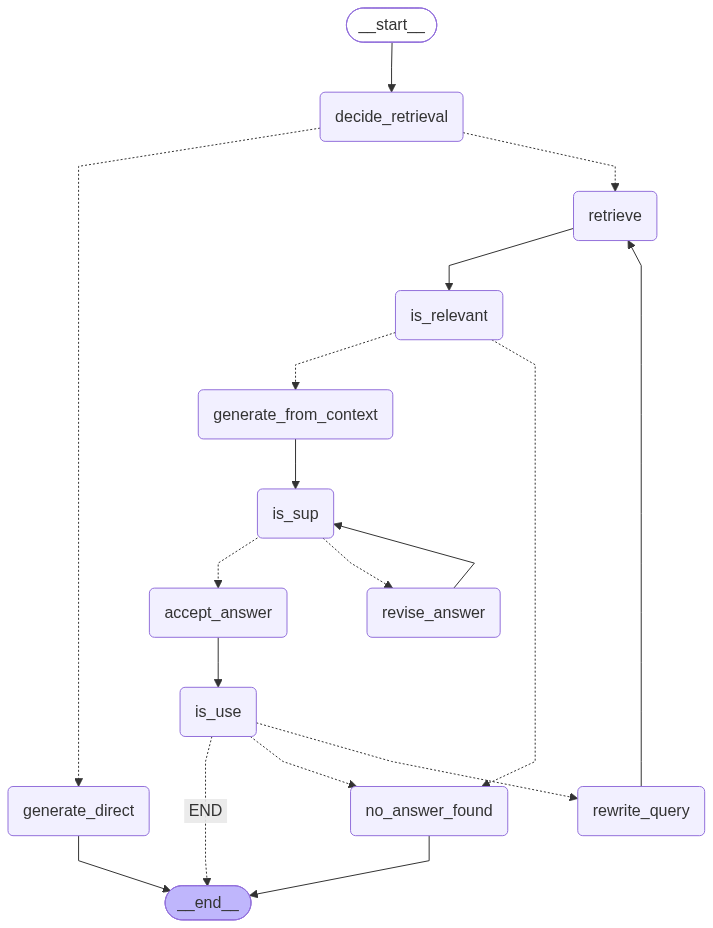

In [45]:
app

In [46]:
# -----------------------------
# Run the graph
# -----------------------------
result = app.invoke(
    {
            "question": "Describe NexaAI’s company culture.",
            "docs": [],
            "relevant_docs": [],
            "context": "",
            "answer": "",
            "is_sup": "",
            "is_use" : "",
            "evidence": [],
            "retries": 0,
        },
        config={"recursion_limit": 8},  # ✅ bump limit
    )

In [47]:


# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", result.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")


===== RAG EXECUTION RESULT =====

Question: Describe NexaAI’s company culture.
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 0

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 4

Relevant docs (source/page):
  1. source=D:\GenAI\LangGraph\document\Company_Policies.pdf, page=0, title=(anonymous)
  2. source=D:\GenAI\LangGraph\document\Company_Policies.pdf, page=0, title=(anonymous)
  3. source=D:\GenAI\LangGraph\document\Company_Profile.pdf, page=0, title=(anonymous)
  4. source=D:\GenAI\LangGraph\document\Company_Profile.pdf, page=1, title=(anonymous)

Verification (IsSUP):
  issup: None
  evidence:
   - NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
   - Bi-annual performance reviews
   - Employees are encouraged to maintain a healthy work-life balance.

Usefulness (IsUSE):
  isuse: None
  reason: The answer directly describes NexaAI's company culture as requested.

Final Answer:
NexaAI’s company culture is buil

In [ ]:
# How many employees does NextAI have
# Describe NextAI's company cultural
# Do NexaAI plans include a free trail? If yes , how many days